# The Colour Compass

This script pulls travel photos from popular destinations from the Unsplash API and extracts dominant colour palettes. It then applies clustering, feature engineering, and similarity analysis to determine possible travel destination aesthetics. This project was made to transform unstructured data (in this case, images) with the help of an AI coding tool.

I created this project to help me determine what colour palette of clothes/outfits I should bring to future vacation destinations. I wanted to combine some things that I enjoy (fashion and travel!) to code. 

- ChatGPT 5.2 was used as the AI coding assistant
- All photos used were taken from the Unsplash API

## Project Overview

This script includes:
- Collecting travel photography metadata via Unsplash API 
- 4 Countries were explored; Greece, Japan, Thailand & Italy
- Freeze the dataset (for reproductivity)
- Download then normalize images
- Extract dominant colours to create a palette (KMeans)
- Explore features (brightness & warmth)
- Compare destination palettes
- Create a "guidebook" of what colours to pack on vacation!

## Importing Packages

In [1]:
import time
import requests ## for API downloads
import numpy as np ## math/arithmetic 
import pandas as pd ## data analysis package
import seaborn as sns ## for colour graphs

from PIL import Image, ImageFile ## image processing 
from io import BytesIO ## helps interpret images

import matplotlib.pyplot as plt ## graphs

from sklearn.cluster import KMeans ## clusterring
from scipy.spatial.distance import cdist ## helps with distance analysis

## Setting up Unsplash API
- Loading in Access Key
- Testing if access key works

In [2]:
from dotenv import load_dotenv  
import os 

load_dotenv(dotenv_path=".env")

ACCESS_KEY = os.getenv("UNSPLASH_ACCESS_KEY") ## grabbing access key

## checking if access key is loaded 
print("Access key loaded:", ACCESS_KEY is not None) 
print("Key length:", len(ACCESS_KEY) if ACCESS_KEY else None) 

Access key loaded: True
Key length: 43


- Access key can't be shared (confidential)
- BUT is needed to access images from Unsplash API
- checking if the access key was loaded

### Testing API

In [3]:
url = "https://api.unsplash.com/search/photos" ## unsplash API url
headers = {"Authorization": f"Client-ID {ACCESS_KEY}"} ## input API key 

params = { ## searching italy travel for testing
    "query": "italy travel",
    "per_page": 3
}

response = requests.get(url, headers=headers, params=params, timeout=30) ## sends request

print("Status code:", response.status_code)

data = response.json() ## return as JSON
print("Number of results:", len(data.get("results", [])))

Status code: 200
Number of results: 3


- Status code: 200 means the request was successful
- returned 3 images like tested

## Destination Search!

In [4]:
DESTINATIONS = {
    "Japan": "tokyo japan travel street", ## search string for unsplash 
    "Italy": "italy travel street architecture",
    "Greece": "greece santorini travel",
    "Thailand": "thailand beach travel"
}

IMAGES_PER_DEST = 40 ## return 40 images per destination

- I chose Japan, Italy, Greece & Thailand as my destinations to colour analyze
- The supporting words are what to search in Unsplash to find images
- 40 images per destination, 160 images total

In [5]:
def unsplash_search(query, per_page=30, page=1): ##searching
    url = "https://api.unsplash.com/search/photos"
    headers = {"Authorization": f"Client-ID {ACCESS_KEY}"}
    params = {
    "query" : query,
    "per_page" : per_page,
    "page" : page,
    "orientation": "landscape" ## keeps images consistent
    }

    r = requests.get(url, headers=headers, params=params, timeout=30) ## sending request
    r.raise_for_status()
    return r.json() ## return as JSON

- Using Unsplash API search endpoint: https://api.unsplash.com/search/photos
- Executed using Access Key
- Returns images as JSON

## Downloading Image metadata from Search
- Loops through the destinations
- Calls API & collects images
- Extracts metadata
- Building a structured dataset
- Ensures a "sleep" time to prevent abuse in rate-limit

In [6]:
rows = [] ## creating storage for metadata

for dest, query in DESTINATIONS.items(): ## loops through destinations
    ## Counters
    collected = 0
    page = 1

    while collected < IMAGES_PER_DEST: ## keep pulling image until reaching 40 per destination
        data = unsplash_search(query=query, per_page=30, page=page) ## 30 images per request (thats the max per page)
        results = data.get("results", []) ## pulls JSON results
        if not results: ## if API returns nothing, break loop
            break
        ## ensures I dont exceed the limit
        for item in results:
            if collected >= IMAGES_PER_DEST:
                break 
            ## what to extract
            rows.append({
                "destination" : dest,
                "query" : query,
                "photo_id" : item["id"],
                "image_small" : item["urls"]["small"],
                "photo_page" : item["links"]["html"],
                "photographer" : item["user"]["name"],
                "photographer_page" : item["user"]["links"]["html"]
            })

            collected += 1 ##increases counter

        page += 1 ## moves to next API page, waits 0.4 seconds
        time.sleep(0.4)

df_meta = pd.DataFrame(rows) ## craeting dataframe

print("Total images collected:", len(df_meta))
df_meta.head() ## display

Total images collected: 160


,destination,query,photo_id,image_small,photo_page,photographer,photographer_page
0,Japan,tokyo japan travel street,0n2FxR6rlKo,https://images.unsplash.com/photo-169094289193...,https://unsplash.com/photos/a-busy-city-street...,TE LUN OU YANG,https://unsplash.com/@telun_photo
1,Japan,tokyo japan travel street,7NX_PkUQ9fQ,https://images.unsplash.com/photo-159682905786...,https://unsplash.com/photos/people-walking-on-...,Kvnga,https://unsplash.com/@kvnga
2,Japan,tokyo japan travel street,f1KrC0Z6Jww,https://images.unsplash.com/photo-167299365449...,https://unsplash.com/photos/a-narrow-city-stre...,Shade,https://unsplash.com/@shade_
3,Japan,tokyo japan travel street,oJMPcUv2CWA,https://images.unsplash.com/photo-159664687165...,https://unsplash.com/photos/people-walking-on-...,Kvnga,https://unsplash.com/@kvnga
4,Japan,tokyo japan travel street,Hiipx7aX2vQ,https://images.unsplash.com/photo-169747226622...,https://unsplash.com/photos/a-city-bus-driving...,shun idota,https://unsplash.com/@itzshunnn


- Columns created: destination, query, photo_id, image_small, photo_page, photographer, photographer_page
- Total images: 160

In [7]:
df_meta.to_csv("metadata_backup.csv", index = False) ## making this dataframe a csv

After collecting image metadata, the dataframe is saved as a csv: metadata_backup.csv
- This reduces dependency on live API calls
- If there is a need for more live API calls, skip this cell

# Colour Analysis & Palette Creation

### loading in metadata dataset

In [8]:
df_meta = pd.read_csv("metadata_backup.csv")

print("Images loaded:", len(df_meta))
df_meta.head() ## display

Images loaded: 160


,destination,query,photo_id,image_small,photo_page,photographer,photographer_page
0,Japan,tokyo japan travel street,0n2FxR6rlKo,https://images.unsplash.com/photo-169094289193...,https://unsplash.com/photos/a-busy-city-street...,TE LUN OU YANG,https://unsplash.com/@telun_photo
1,Japan,tokyo japan travel street,7NX_PkUQ9fQ,https://images.unsplash.com/photo-159682905786...,https://unsplash.com/photos/people-walking-on-...,Kvnga,https://unsplash.com/@kvnga
2,Japan,tokyo japan travel street,f1KrC0Z6Jww,https://images.unsplash.com/photo-167299365449...,https://unsplash.com/photos/a-narrow-city-stre...,Shade,https://unsplash.com/@shade_
3,Japan,tokyo japan travel street,oJMPcUv2CWA,https://images.unsplash.com/photo-159664687165...,https://unsplash.com/photos/people-walking-on-...,Kvnga,https://unsplash.com/@kvnga
4,Japan,tokyo japan travel street,Hiipx7aX2vQ,https://images.unsplash.com/photo-169747226622...,https://unsplash.com/photos/a-city-bus-driving...,shun idota,https://unsplash.com/@itzshunnn


In [9]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

- Web images are sometimes incomplete, this line ensures PIL still loads these images anyways

### Normalization

In [10]:
## downloads image
def download_image(url): 
    r = requests.get(url, timeout=30)
    r.raise_for_status() ## if download fails, stop

    img = Image.open(BytesIO(r.content)) 

    ## normalization
    if img.mode not in ["RGB", "RGBA"]:
        img = img.convert("RBG")
    elif img.mode == "RGBA":
        img = img.convert("RBG")

    return img

- images online can come in different formats
- this block ensures e-channel RGB standardization 
- KMeans

## Dominant Colours Extraction

In [11]:
## extracting 5 dominant colours from a resized image
def dominant_colours(img, k=5, sample_pixels=3000, resize=(150, 150)):

    img = img.resize(resize) ## resizing
    arr = np.array(img) ## converting to array

    # Ensure correct shape
    if arr.ndim != 3 or arr.shape[2] != 3:
        arr = np.stack([arr] * 3, axis=-1) 

    arr = arr.reshape(-1, 3) #3 flatten pixels

    ## randomly sample 3000 pixels
    if arr.shape[0] > sample_pixels:
        idx = np.random.choice(arr.shape[0], sample_pixels, replace=False)
        arr = arr[idx]

    ## grouping pixels into 5 clusters
    km = KMeans(n_clusters=k, n_init=5, random_state=42)
    km.fit(arr)

    ## extract centers, gives 5 rgb colours
    centers = km.cluster_centers_.astype(int)

    ## calculate colour domination
    labels, counts = np.unique(km.labels_, return_counts=True)
    proportions = counts / counts.sum()

    ## sort by dominance
    order = np.argsort(-proportions)

    return centers[order], proportions[order]

- This block of code extracts 5 dominant colours from a resized immage
- There are so many pixels in images, this code randomly samples 3000

## Testing!

In [12]:
## testing 1 image

row = df_meta.iloc[0]

img = download_image(row["image_small"])
centers, props = dominant_colours(img)

print("Centers shape:", centers.shape)
print("Proportions sum:", props.sum())
centers

Centers shape: (5, 3)
Proportions sum: 1.0


array([[143, 125, 114],
       [179, 164, 154],
       [104,  80,  72],
       [ 48,  38,  33],
       [235, 235, 233]])

- This took 1 image (the first) from my metadata dataset and tested it
- Downloads it, then extracts 5 colours

## Applying to all Images

In [13]:
palette_rows = [] ## storing colour rows
failed = 0 ## counts images that failed

for i, row in df_meta.iterrows(): ## loop for all images, downloads & extracts colour
    try: ## if 1 image fails, it doesn't crash the whole script
        img = download_image(row["image_small"])
        centers, props = dominant_colours(img)

        for rank, (rgb, w) in enumerate(zip(centers, props), start=1): ## expand each image into 5 rows
            palette_rows.append({
                "destination": row["destination"],
                "photo_id": row["photo_id"],
                "rank": rank,
                "r": int(rgb[0]),
                "g": int(rgb[1]),
                "b": int(rgb[2]),
                "weight": float(w)
            })

    except Exception as e: #3 if image fails, count but continue code
        failed += 1
        if failed <= 3:
            print("Failed image:", i, "|", str(e))
        continue

    if (i + 1) % 20 == 0: ## progress updates 
        print(f"Processed {i+1}/{len(df_meta)}")

df_colours = pd.DataFrame(palette_rows) ## list becomes a structured table

print("\nDone.")
print("Total colour rows:", len(df_colours))
print("Images failed:", failed)

df_colours.head() ## display

Processed 20/160
Processed 40/160
Processed 60/160
Processed 80/160
Processed 100/160
Processed 120/160
Processed 140/160
Processed 160/160

Done.
Total colour rows: 800
Images failed: 0


,destination,photo_id,rank,r,g,b,weight
0,Japan,0n2FxR6rlKo,1,142,124,114,0.340667
1,Japan,0n2FxR6rlKo,2,180,164,154,0.260333
2,Japan,0n2FxR6rlKo,3,97,75,67,0.200000
3,Japan,0n2FxR6rlKo,4,39,31,26,0.133667
4,Japan,0n2FxR6rlKo,5,232,233,230,0.065333


- All images successfully ran through the code
- Downloaded, then extracted 5 dominant colours

### Saving as CSV

In [14]:
df_colours.to_csv("colours_backup.csv", index=False) ## colour dataframe to csv

- Saving as CSV for colour analysis

## Colour Analysis

### RGB to HEX
- converts RGB (e.g 142, 125, 115) to HEX (e.g #8e7d73)

In [15]:
def rgb_to_hex(r, g, b):
    return "#{:02x}{:02x}{:02x}".format(r, g, b) ## converting to hex from rgb

df_colours["hex"] = df_colours.apply( ## apply row by row for new column, dominant colours
    lambda x: rgb_to_hex(x["r"], x["g"], x["b"]),
    axis=1
)

df_colours.head()

,destination,photo_id,rank,r,g,b,weight,hex
0,Japan,0n2FxR6rlKo,1,142,124,114,0.340667,#8e7c72
1,Japan,0n2FxR6rlKo,2,180,164,154,0.260333,#b4a49a
2,Japan,0n2FxR6rlKo,3,97,75,67,0.200000,#614b43
3,Japan,0n2FxR6rlKo,4,39,31,26,0.133667,#271f1a
4,Japan,0n2FxR6rlKo,5,232,233,230,0.065333,#e8e9e6


- HEX is easier to visualize
- HEX can be used directly with matplotlib (good for analysis!!)

### Destination Palettes

In [16]:
dest_palette = (
    df_colours.groupby(["destination", "hex"], as_index=False)["weight"] ## combine identical colours, add up weight
    .sum()
    .sort_values(["destination", "weight"], ascending=[True, False]) 
)

dest_palette.head() ## display

,destination,hex,weight
189,Greece,#e7e9ec,0.545000
168,Greece,#ced4df,0.473000
196,Greece,#f4eeeb,0.439000
87,Greece,#6fbafa,0.406333
176,Greece,#d8e0e9,0.380333


- Combining colours that are identical and adding up their weight
- This creates an overall dominant colour palette of a specific destination

### Top Colours

In [17]:
topN = 8 ## keep 8 dominant colours
dest_top = dest_palette.groupby("destination").head(topN)

dest_top.head(16) #3 display

,destination,hex,weight
189,Greece,#e7e9ec,0.545000
168,Greece,#ced4df,0.473000
196,Greece,#f4eeeb,0.439000
87,Greece,#6fbafa,0.406333
176,Greece,#d8e0e9,0.380333
86,Greece,#6f6f77,0.378333
198,Greece,#f4f5eb,0.377667
70,Greece,#595352,0.373667
235,Italy,#4a3d33,0.666333
318,Italy,#95989a,0.501000


- This simplifies the colour palette

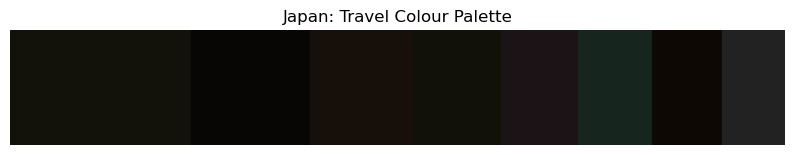

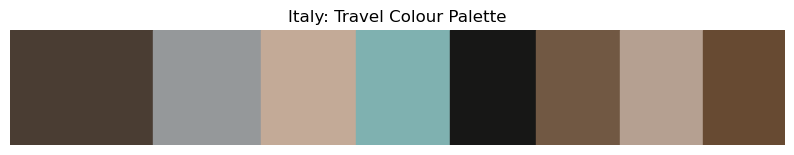

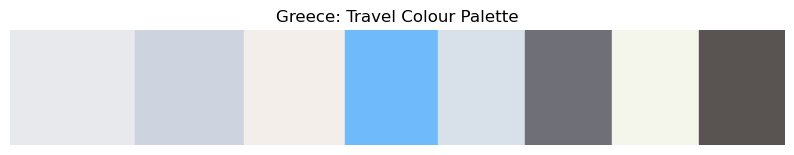

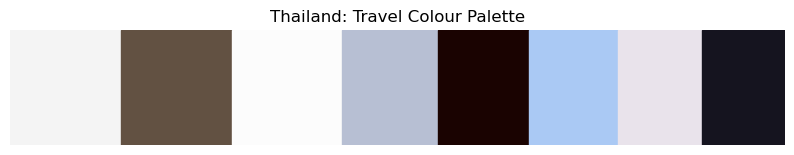

In [18]:
def show_palette(dest):
    subset = dest_top[dest_top["destination"] == dest]
    colors = subset["hex"].tolist()
    weights = subset["weight"].tolist() 

    fig, ax = plt.subplots(figsize=(10, 1.5))
    start = 0
    total = sum(weights)

    for c, w in zip(colors, weights):
        width = w / total
        ax.add_patch(plt.Rectangle((start, 0), width, 1, color=c)) ## if colour weight is large, takes up more space visually
        start += width

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.title(f"{dest}: Travel Colour Palette")
    plt.show()

for d in df_meta["destination"].unique(): ## generating a palette for each destination
    show_palette(d)

In [19]:
destinations = dest_top["destination"].unique()

palette_vector = {}

for dest in destinations:
    subset = dest_top[dest_top["destination"] == dest]
    rgb_vals = df_colours[df_colours["destination"] == dest][["r","g","b"]].values
    palette_vector[dest] = rgb_vals.mean(axis=0)

dist_matrix = [] ## creating distance matrix

for d1 in destinations:
    row = []
    for d2 in destinations:
        dist = np.linalg.norm(palette_vector[d1] - palette_vector[d2]) ## how far apart are each country in RGB 
        row.append(dist)
    dist_matrix.append(row)

dist_df = pd.DataFrame(dist_matrix, index=destinations, columns=destinations)

dist_df

,Greece,Italy,Japan,Thailand
Greece,0.000000,26.197683,43.685999,20.194985
Italy,26.197683,0.000000,27.999843,8.741174
Japan,43.685999,27.999843,0.000000,27.574998
Thailand,20.194985,8.741174,27.574998,0.000000


- Calculates colour palette distance between destinations
- Small distance = similarity in colours
- Larger Distance = vast differences in aesthetics
- e.g Japan and Greece have very different palettes

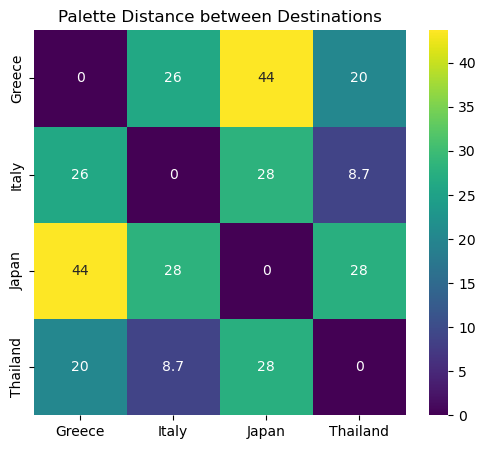

In [20]:
plt.figure(figsize=(6,5)) ## figure size
sns.heatmap(dist_df, annot=True, cmap="viridis") ## creating heat map

plt.title("Palette Distance between Destinations")
plt.show() ## display

### Takeaways:
- Italy & Thailand are very close at around 8.7
- Japan and Greece differ more at around 40

Results are similar to the table above, this is a more visual representation 

## Computing Brightness per Country
- using the luminance formula
- green contributes most, blue contributes least

In [21]:
df_colours["brightness"] = ( ## standard luminance formula
    0.299 * df_colours["r"]+
    0.587 * df_colours["g"]+
    0.114 * df_colours["b"]
)

## avg brightness per country
brightness_summary = (
    df_colours.groupby("destination")["brightness"]
    .mean()
    .sort_values(ascending=False)
)

brightness_summary

destination
Greece      132.153535
Thailand    127.475670
Italy       127.460645
Japan       110.568680
Name: brightness, dtype: float64

### Takeaways:
- Greece is the lightest
- Japan is darkest

Matches the palette above

## Computing warmth 
- red > blue = warm
- blue> red - cool

In [22]:
df_colours["warmth"] = df_colours["r"] - df_colours["b"]

warmth_summary = (
    df_colours.groupby("destination")["warmth"]
    .mean() ## average per country
    .sort_values(ascending=False) ## sort
) 

warmth_summary

destination
Italy       17.65
Japan        9.09
Thailand     6.52
Greece     -14.48
Name: warmth, dtype: float64

### Takeaways: 
- Italy is the warmest
- Greece is the coolest (negative #)

### Aesthetics Profile

In [23]:
## features matrix
aesthetics_profile = pd.DataFrame({
    "brightness": brightness_summary,
    "warmth": warmth_summary
})

aesthetics_profile

,brightness,warmth
destination,,
Greece,132.153535,-14.48
Italy,127.460645,17.65
Japan,110.568680,9.09
Thailand,127.475670,6.52


- Displaying warmth & brightness

## Clustering
- grouping countries by similar aesthetics

In [24]:
X = aesthetics_profile.values

##grouping
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

aesthetics_profile["cluster"] = clusters

aesthetics_profile

C:\Users\ashle\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,brightness,warmth,cluster
destination,,,
Greece,132.153535,-14.48,1
Italy,127.460645,17.65,0
Japan,110.568680,9.09,1
Thailand,127.475670,6.52,1


- Cluster 0 = warm & bright
- Cluster 1 = cool & bright

## Aesthetic Positioning

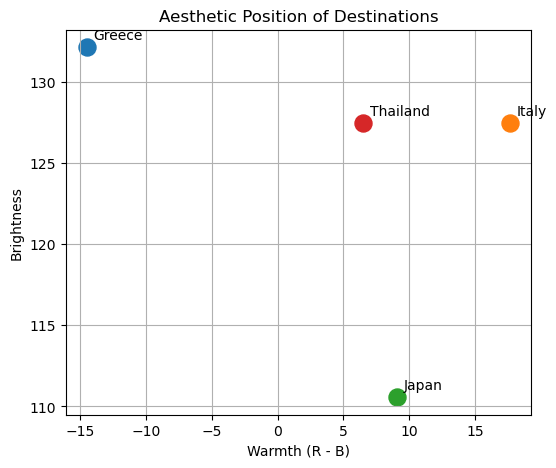

In [25]:
plt.figure(figsize=(6,5)) ## using matplotlib

for dest in aesthetics_profile.index:
    x = aesthetics_profile.loc[dest, "warmth"]
    y = aesthetics_profile.loc[dest, "brightness"]
    c = aesthetics_profile.loc[dest, "cluster"]

    plt.scatter(x, y, s=150)
    plt.text(x+0.5, y+0.5, dest)

## labels/title
plt.xlabel("Warmth (R - B)")
plt.ylabel("Brightness")
plt.title("Aesthetic Position of Destinations")
plt.grid(True)
plt.show()

## Recommendations!!
- A colour guidebook for your trip

#### Based off warmth & brightness results:

In [26]:
def rec_outfit(destination):
    b = aesthetics_profile.loc[destination, "brightness"]
    w = aesthetics_profile.loc[destination, "warmth"]

    print(f"\nDestination: {destination}")

    if b > aesthetics_profile["brightness"].mean(): ## if brightness is greater than the avg
        print("Lighter tones recommended (linen, white, light/sky blue)")
    else:
        print("Dark neutrals recommended (black, charcoal, forest, deep brown)") ## if not then..

    if w > 0: ## if warmth is greater than 0 
        print("Warm tones compliment environment(terracotta, sand, beiges)")
    else: ## if not..
        print("Cool tones compliment environment(silver, sky blue, navy)")

for dest in aesthetics_profile.index:
    rec_outfit(dest)      


Destination: Greece
Lighter tones recommended (linen, white, light/sky blue)
Cool tones compliment environment(silver, sky blue, navy)

Destination: Italy
Lighter tones recommended (linen, white, light/sky blue)
Warm tones compliment environment(terracotta, sand, beiges)

Destination: Japan
Dark neutrals recommended (black, charcoal, forest, deep brown)
Warm tones compliment environment(terracotta, sand, beiges)

Destination: Thailand
Lighter tones recommended (linen, white, light/sky blue)
Warm tones compliment environment(terracotta, sand, beiges)


#### Based on palette colours

In [27]:
def rec_outfit_v2(destination):
    subset = dest_top[dest_top["destination"] == destination]
    top_colours = subset["hex"].head(3).tolist()

    print(f"\nDestination: {destination}")
    print("Destination palette:", ", ".join(top_colours))

    print("\nOutfit Guide:")
    
    ## basics
    print("- Use one dominant palette colour as a base piece")
    print("- Pair with a neutral that is in the palette")

    print("\nSuggested Outfit Idea:")
    
    if destination == "Japan": ## Japan results
        print("Structured and/or monochrome dark outfit (charcoal / deep green / muted brown)")
        print("Minimal contrast, clean silhouettes")

    elif destination == "Italy": ## Italy results
        print("Earth tones (sand, terracotta, warm neutrals)")
        print("Soft tailoring, sun-washed textures")

    elif destination == "Greece": ## Greece results
        print("Light fabrics (white, linen, soft blue, cool neutrals)")
        print("Airy, coastal vibe")

    elif destination == "Thailand": ## Thailand results
        print("Light top & strong contrast piece")
        print("Breathable fabrics with subtle colour accents")

In [28]:
for dest in aesthetics_profile.index:
    rec_outfit_v2(dest)


Destination: Greece
Destination palette: #e7e9ec, #ced4df, #f4eeeb

Outfit Guide:
- Use one dominant palette colour as a base piece
- Pair with a neutral that is in the palette

Suggested Outfit Idea:
Light fabrics (white, linen, soft blue, cool neutrals)
Airy, coastal vibe

Destination: Italy
Destination palette: #4a3d33, #95989a, #c3aa97

Outfit Guide:
- Use one dominant palette colour as a base piece
- Pair with a neutral that is in the palette

Suggested Outfit Idea:
Earth tones (sand, terracotta, warm neutrals)
Soft tailoring, sun-washed textures

Destination: Japan
Destination palette: #12110a, #080605, #17100a

Outfit Guide:
- Use one dominant palette colour as a base piece
- Pair with a neutral that is in the palette

Suggested Outfit Idea:
Structured and/or monochrome dark outfit (charcoal / deep green / muted brown)
Minimal contrast, clean silhouettes

Destination: Thailand
Destination palette: #f4f4f4, #625142, #fcfcfc

Outfit Guide:
- Use one dominant palette colour as a b

## Key Takeaways

##### Travel destinations have distinct colour palettes!

By extracting dominant colours, I observed that each destination has a consistent visual signature

- Greece has a lighter, softer colour palette
- Japan has a darker palette (black, browns, deep greens)
- Thailand presents a mix of darker and lighter tones
- Italy shares a slightly more diverse range of colours in the palette

Colour similarity is quantifiable! 

- I was able to explore distances in colour similarities
- Japan & Greece were the most visually distinct

Brightness & warmth can capture the mood aesthetic

- Brightness (perceived luminance)
- Warmth (Red − Blue)
- Created an aesthetic profile

Data Can Translate Visual Aesthetics Into Actionable Insight

- Feature engineering
- Clustering
- Turned unstructured data into data for analysis

Converts data images into meaningful and data-driven recommendations

This script allows me (or anyone else) wanting to coordinate outfits with data-driven recommendations!